<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_neural-network-using-numpy-keras-pytorch/blob/main/colab_e_tensorflow_variants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab E — 3-Layer Neural Network: TensorFlow 4 Variants

This single notebook contains **all four TensorFlow approaches**:

| Variant | Description | Abstraction Level |
|---|---|---|
| **E-i**   | TF from scratch — `tf.Variable` + `GradientTape` | Lowest |
| **E-ii**  | TF with builtin layers — `tf.keras.layers.Dense` | Low |
| **E-iii** | Functional API — `keras.Input` + layer composition | Medium |
| **E-iv**  | High-level API — `model.compile` + `model.fit` | Highest |

**All variants use the same:** architecture (3→64→32→1), data, and nonlinear regression problem.

In [1]:
# ─────────────────────────────────────────────
# SHARED SETUP: Imports & Data
# ─────────────────────────────────────────────
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow version: {tf.__version__}')

# ── Shared data ───────────────────────────────
def generate_data(n=2000):
    x1 = np.random.uniform(-np.pi, np.pi, n).astype(np.float32)
    x2 = np.random.uniform(-np.pi, np.pi, n).astype(np.float32)
    x3 = np.random.uniform(-2, 2, n).astype(np.float32)
    noise = np.random.normal(0, 0.05, n).astype(np.float32)
    y = np.sin(x1)*np.cos(x2) + x3**2 + 0.5*np.sin(x1*x3) + noise
    X = np.stack([x1, x2, x3], axis=1)
    return X, y.reshape(-1, 1)

X_np, y_np = generate_data()
X_mean, X_std = X_np.mean(0), X_np.std(0)
y_mean, y_std = y_np.mean(), y_np.std()
X_np = (X_np - X_mean) / X_std
y_np = (y_np - y_mean) / y_std

split = int(0.8 * len(X_np))
X_tr, X_te = X_np[:split], X_np[split:]
y_tr, y_te = y_np[:split], y_np[split:]

print(f'Train: {X_tr.shape}  Test: {X_te.shape}')

def plot_results(history_dict, y_te, y_pred, title_prefix):
    """Shared plotting function for all variants."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history_dict['train'], label='Train', color='steelblue', lw=2)
    axes[0].plot(history_dict['val'],   label='Val',   color='tomato',    lw=2)
    axes[0].set_yscale('log')
    axes[0].set_title(f'{title_prefix} — Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    y_true_d = y_te * y_std + y_mean
    y_pred_d = y_pred * y_std + y_mean
    axes[1].scatter(y_true_d, y_pred_d, alpha=0.4, s=10, color='steelblue')
    lims = [y_true_d.min(), y_true_d.max()]
    axes[1].plot(lims, lims, 'r--', lw=2)
    axes[1].set_title('Predicted vs True')
    axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')
    axes[1].grid(True, alpha=0.3)

    resid = (y_true_d - y_pred_d).ravel()
    axes[2].hist(resid, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
    axes[2].axvline(0, color='red', linestyle='--', lw=2)
    axes[2].set_title(f'Residuals  Std={resid.std():.4f}')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout(); plt.savefig(f'{title_prefix.replace(" ","_")}_results.png', dpi=100)
    plt.show()

    r2  = r2_score(y_true_d, y_pred_d)
    mae = mean_absolute_error(y_true_d, y_pred_d)
    print(f'{title_prefix} — R²: {r2:.4f}  MAE: {mae:.4f}  RMSE: {np.sqrt(np.mean(resid**2)):.4f}')

TensorFlow version: 2.19.0
Train: (1600, 3)  Test: (400, 3)


---
# Variant E-i: TensorFlow from Scratch

**No high-level API.** We use:
- `tf.Variable` for all weights and biases
- `tf.GradientTape` to record operations for differentiation
- Manual gradient application with `optimizer.apply_gradients()`
- `tf.einsum` for matrix operations

This is the **TensorFlow equivalent of Colab A** (NumPy scratch).

E-i: TensorFlow from scratch
Epoch    1: train=1.253395  val=0.688524
Epoch  100: train=0.016947  val=0.022760
Epoch  200: train=0.009769  val=0.015643
Epoch  300: train=0.007128  val=0.013470
Epoch  400: train=0.004931  val=0.009451
Epoch  500: train=0.004721  val=0.009366


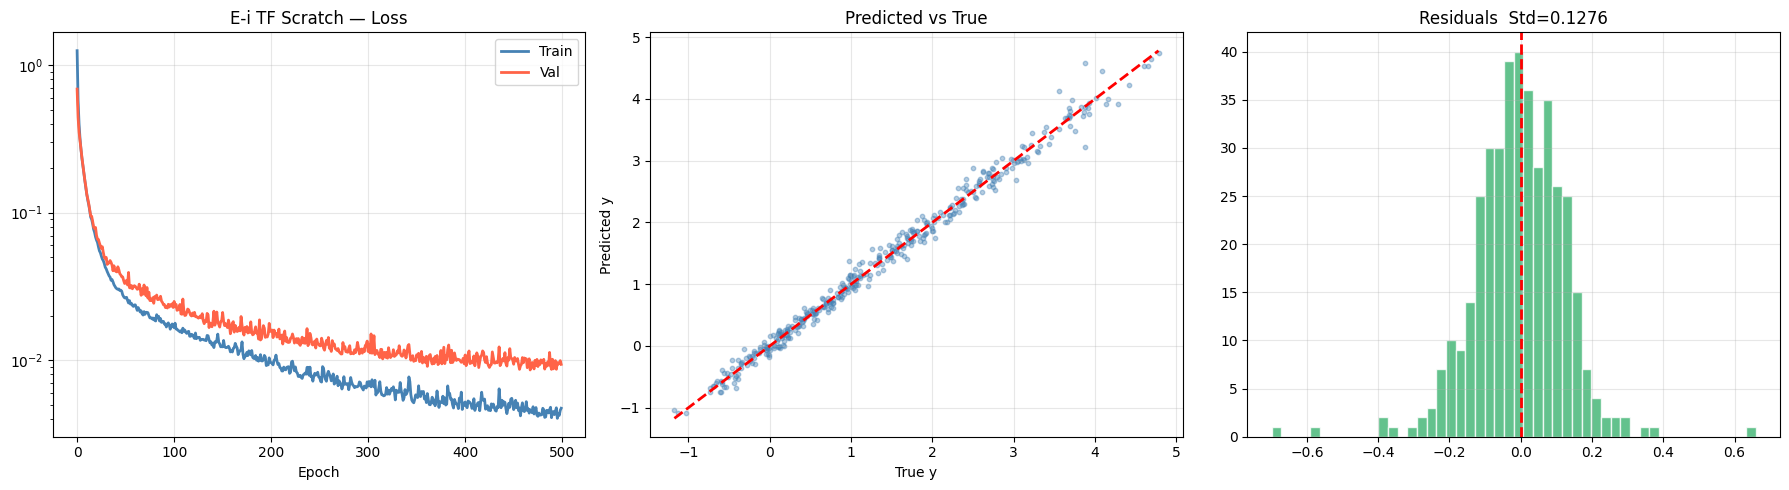

E-i TF Scratch — R²: 0.9905  MAE: 0.0950  RMSE: 0.1277


In [2]:
# ═════════════════════════════════════════════
# VARIANT E-i: TF from Scratch (GradientTape)
# ═════════════════════════════════════════════

print('=' * 50)
print('E-i: TensorFlow from scratch')
print('=' * 50)

# ── Weight initialization ─────────────────────
def make_variable(shape, name):
    """He-initialized tf.Variable."""
    fan_in = shape[0]
    std = tf.sqrt(2.0 / fan_in)
    init = tf.random.normal(shape, stddev=std)
    return tf.Variable(init, name=name, dtype=tf.float32)

# Layer 1: 3 → 64
W1_ei = make_variable([3,  64], 'W1')
b1_ei = tf.Variable(tf.zeros([1, 64]), name='b1')

# Layer 2: 64 → 32
W2_ei = make_variable([64, 32], 'W2')
b2_ei = tf.Variable(tf.zeros([1, 32]), name='b2')

# Layer 3: 32 → 1
W3_ei = make_variable([32, 1],  'W3')
b3_ei = tf.Variable(tf.zeros([1, 1]),  name='b3')

vars_ei = [W1_ei, b1_ei, W2_ei, b2_ei, W3_ei, b3_ei]

def forward_ei(X):
    """Forward pass using tf.einsum and tf.nn.relu."""
    # tf.einsum('bi,ij->bj') = matrix multiply along shared dim i
    Z1 = tf.einsum('bi,ij->bj', X, W1_ei) + b1_ei
    A1 = tf.nn.relu(Z1)
    Z2 = tf.einsum('bi,ij->bj', A1, W2_ei) + b2_ei
    A2 = tf.nn.relu(Z2)
    Z3 = tf.einsum('bi,ij->bj', A2, W3_ei) + b3_ei
    return Z3  # linear output

# ── Training loop with GradientTape ──────────
optimizer_ei = tf.keras.optimizers.Adam(learning_rate=0.001)

EPOCHS     = 500
BATCH_SIZE = 64
n          = X_tr.shape[0]

hist_ei = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    idx = np.random.permutation(n)
    X_s, y_s = X_tr[idx], y_tr[idx]
    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, n, BATCH_SIZE):
        Xb = tf.constant(X_s[start:start+BATCH_SIZE])
        yb = tf.constant(y_s[start:start+BATCH_SIZE])

        # GradientTape records all ops inside the 'with' block
        with tf.GradientTape() as tape:
            y_pred = forward_ei(Xb)
            loss   = tf.reduce_mean((y_pred - yb) ** 2)

        # Compute gradients w.r.t. all variables
        grads = tape.gradient(loss, vars_ei)

        # Apply gradients (equivalent to optimizer.step() in PyTorch)
        optimizer_ei.apply_gradients(zip(grads, vars_ei))

        epoch_loss += loss.numpy()
        n_batches  += 1

    tr_loss = epoch_loss / n_batches
    y_val_pred = forward_ei(tf.constant(X_te))
    te_loss = tf.reduce_mean((y_val_pred - y_te)**2).numpy()
    hist_ei['train'].append(tr_loss)
    hist_ei['val'].append(te_loss)

    if epoch % 100 == 0 or epoch == 1:
        print(f'Epoch {epoch:>4}: train={tr_loss:.6f}  val={te_loss:.6f}')

y_pred_ei = forward_ei(tf.constant(X_te)).numpy()
plot_results(hist_ei, y_te, y_pred_ei, 'E-i TF Scratch')

---
# Variant E-ii: TF with Builtin Dense Layers

Still manual training loop via `GradientTape`, but we use **`tf.keras.layers.Dense`**  
instead of raw `tf.Variable`. No `model.compile()` or `model.fit()`.

E-ii: TF builtin Dense layers, manual GradientTape
Parameters: 2369
Epoch    1: train=0.931349  val=0.641430
Epoch  100: train=0.014347  val=0.021629
Epoch  200: train=0.008488  val=0.012104
Epoch  300: train=0.005722  val=0.008904
Epoch  400: train=0.005391  val=0.008625
Epoch  500: train=0.003990  val=0.009032


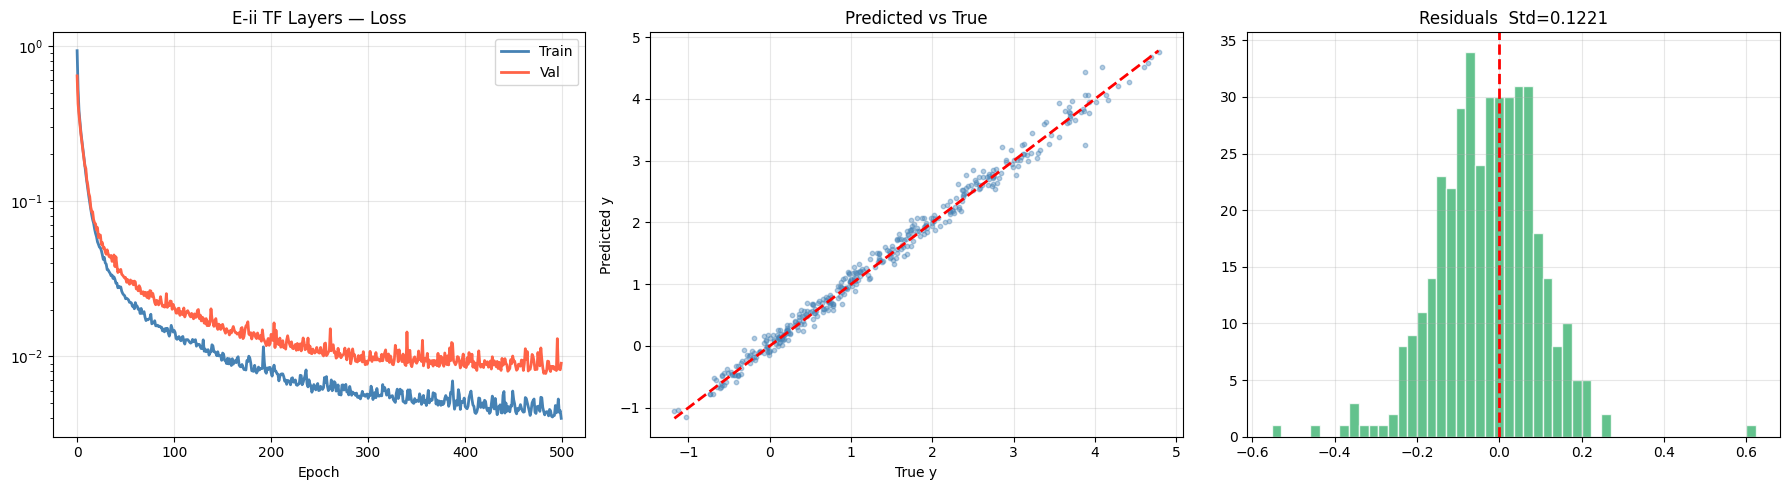

E-ii TF Layers — R²: 0.9908  MAE: 0.0967  RMSE: 0.1254


In [3]:
# ═════════════════════════════════════════════
# VARIANT E-ii: TF Builtin Layers + Manual Loop
# ═════════════════════════════════════════════

print('=' * 50)
print('E-ii: TF builtin Dense layers, manual GradientTape')
print('=' * 50)

class DeepNetTFLayers(tf.keras.Model):
    """3-layer network using tf.keras.layers, but manually trained.

    Differences from E-i:
    - Dense layers handle weight creation (no manual tf.Variable)
    - We still use GradientTape for training (no model.fit)
    - Parameters accessible via self.trainable_variables
    """
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(64, activation='relu',
                                         kernel_initializer='he_normal')
        self.d2 = tf.keras.layers.Dense(32, activation='relu',
                                         kernel_initializer='he_normal')
        self.d3 = tf.keras.layers.Dense(1,  activation='linear',
                                         kernel_initializer='he_normal')

    def call(self, x, training=False):
        x = self.d1(x)
        x = self.d2(x)
        return self.d3(x)

model_eii     = DeepNetTFLayers()
optimizer_eii = tf.keras.optimizers.Adam(learning_rate=0.001)

# Build model (needed to init layer weights before accessing trainable_variables)
_ = model_eii(tf.zeros([1, 3]))
print(f'Parameters: {sum(np.prod(v.shape) for v in model_eii.trainable_variables)}')

hist_eii = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    idx = np.random.permutation(n)
    X_s, y_s = X_tr[idx], y_tr[idx]
    epoch_loss = 0.0; n_batches = 0

    for start in range(0, n, BATCH_SIZE):
        Xb = tf.constant(X_s[start:start+BATCH_SIZE])
        yb = tf.constant(y_s[start:start+BATCH_SIZE])

        with tf.GradientTape() as tape:
            y_pred = model_eii(Xb, training=True)
            loss   = tf.reduce_mean((y_pred - yb)**2)

        # trainable_variables includes all Dense layer W and b
        grads = tape.gradient(loss, model_eii.trainable_variables)
        optimizer_eii.apply_gradients(zip(grads, model_eii.trainable_variables))
        epoch_loss += loss.numpy(); n_batches += 1

    tr_loss = epoch_loss / n_batches
    y_vp = model_eii(tf.constant(X_te), training=False)
    te_loss = tf.reduce_mean((y_vp - y_te)**2).numpy()
    hist_eii['train'].append(tr_loss)
    hist_eii['val'].append(te_loss)

    if epoch % 100 == 0 or epoch == 1:
        print(f'Epoch {epoch:>4}: train={tr_loss:.6f}  val={te_loss:.6f}')

y_pred_eii = model_eii(tf.constant(X_te)).numpy()
plot_results(hist_eii, y_te, y_pred_eii, 'E-ii TF Layers')

---
# Variant E-iii: TF Functional API

The Keras **Functional API** builds models as a DAG of layers.  
Unlike `Sequential`, it supports multiple inputs/outputs and skip connections.

E-iii: Keras Functional API


Model: "functional_3layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)


Stopped at epoch: 500


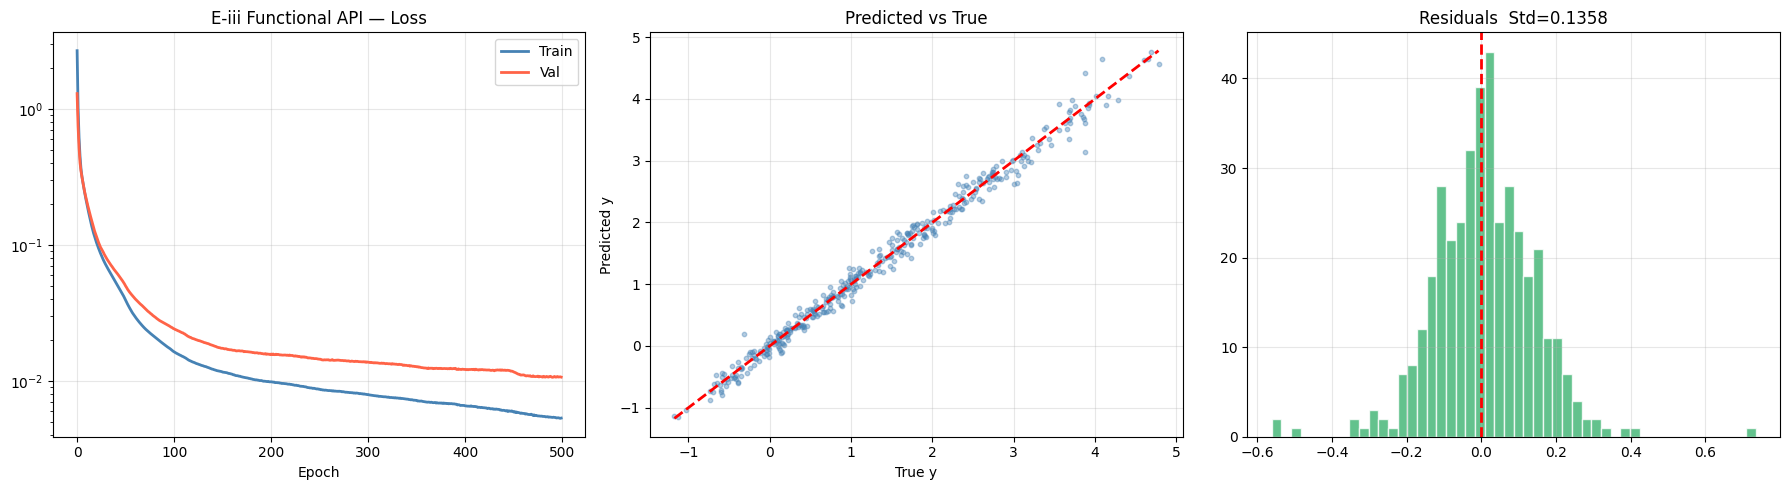

E-iii Functional API — R²: 0.9892  MAE: 0.1017  RMSE: 0.1360


In [4]:
# ═════════════════════════════════════════════
# VARIANT E-iii: Keras Functional API
# ═════════════════════════════════════════════

print('=' * 50)
print('E-iii: Keras Functional API')
print('=' * 50)

# Functional API: define the graph explicitly
# - keras.Input() defines the entry point (shape only, no data)
# - Each layer call returns a tensor (symbolic)
# - keras.Model(inputs, outputs) compiles the graph

inputs  = tf.keras.Input(shape=(3,), name='input_layer')

x = tf.keras.layers.Dense(
    64, activation='relu',
    kernel_initializer='he_normal',
    name='hidden_1'
)(inputs)

x = tf.keras.layers.Dense(
    32, activation='relu',
    kernel_initializer='he_normal',
    name='hidden_2'
)(x)

outputs = tf.keras.layers.Dense(
    1, activation='linear',
    name='output'
)(x)

# Build the Model object from input tensor → output tensor
model_eiii = tf.keras.Model(inputs=inputs, outputs=outputs, name='functional_3layer')
model_eiii.summary()

# Compile: attach loss + optimizer to the model
model_eiii.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# model.fit handles the entire training loop
history_eiii = model_eiii.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=500,
    batch_size=64,
    verbose=0,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)
    ]
)

print(f'\nStopped at epoch: {len(history_eiii.history["loss"])}')
hist_eiii = {
    'train': history_eiii.history['loss'],
    'val':   history_eiii.history['val_loss']
}
y_pred_eiii = model_eiii.predict(X_te, verbose=0)
plot_results(hist_eiii, y_te, y_pred_eiii, 'E-iii Functional API')

---
# Variant E-iv: TF High-Level API (Sequential)

The simplest Keras approach — `Sequential` stacks layers linearly.  
One line builds the model; `model.fit` handles everything.

E-iv: Sequential high-level API


Model: "sequential_3layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)


Stopped at epoch: 497


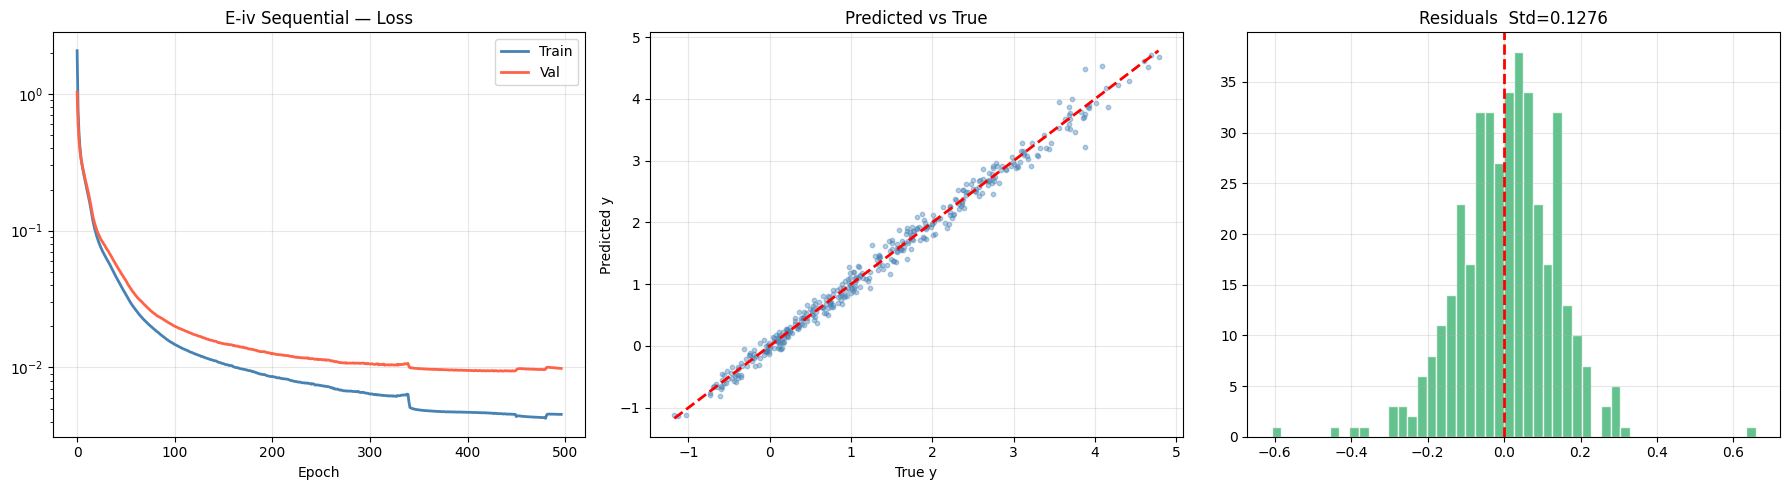

E-iv Sequential — R²: 0.9905  MAE: 0.0978  RMSE: 0.1278


In [5]:
# ═════════════════════════════════════════════
# VARIANT E-iv: High-Level Sequential API
# ═════════════════════════════════════════════

print('=' * 50)
print('E-iv: Sequential high-level API')
print('=' * 50)

model_eiv = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1,  activation='linear'),
], name='sequential_3layer')

model_eiv.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_eiv.summary()

history_eiv = model_eiv.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=500,
    batch_size=64,
    verbose=0,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)
    ]
)

print(f'\nStopped at epoch: {len(history_eiv.history["loss"])}')
hist_eiv = {
    'train': history_eiv.history['loss'],
    'val':   history_eiv.history['val_loss']
}
y_pred_eiv = model_eiv.predict(X_te, verbose=0)
plot_results(hist_eiv, y_te, y_pred_eiv, 'E-iv Sequential')

---
# Final Comparison: All 4 TF Variants

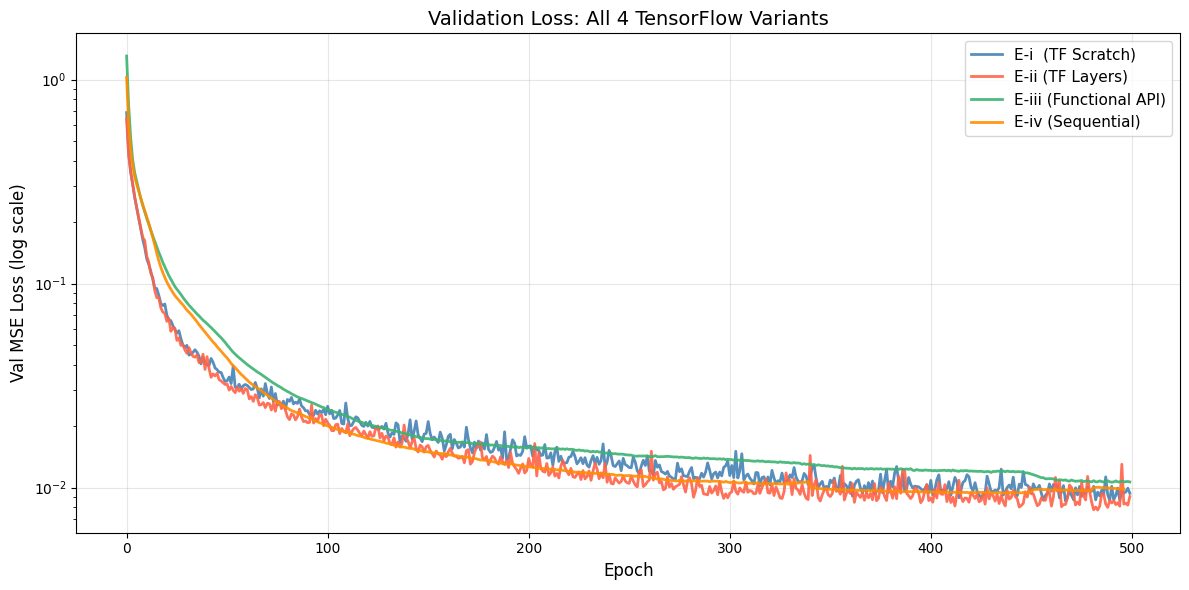


Variant                     Final Val Loss        API Level
E-i  TF Scratch                   0.009366  Raw tf.Variable
E-ii TF Layers                    0.009032  Dense + GradTape
E-iii Functional API              0.010657      keras.Model
E-iv Sequential                   0.009829  model.compile/fit


In [6]:
# ─────────────────────────────────────────────
# COMPARISON: All variants on same plot
# ─────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

variants = [
    (hist_ei,    'E-i  (TF Scratch)',     'steelblue'),
    (hist_eii,   'E-ii (TF Layers)',      'tomato'),
    (hist_eiii,  'E-iii (Functional API)','mediumseagreen'),
    (hist_eiv,   'E-iv (Sequential)',     'darkorange'),
]

for hist, label, color in variants:
    ax.plot(hist['val'], label=label, color=color, lw=2, alpha=0.9)

ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Val MSE Loss (log scale)', fontsize=12)
ax.set_title('Validation Loss: All 4 TensorFlow Variants', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('colab_e_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
print('\n' + '='*65)
print(f'{"Variant":<25}  {"Final Val Loss":>15}  {"API Level":>15}')
print('='*65)
rows = [
    ('E-i  TF Scratch',      hist_ei["val"][-1],   'Raw tf.Variable'),
    ('E-ii TF Layers',       hist_eii["val"][-1],  'Dense + GradTape'),
    ('E-iii Functional API', hist_eiii["val"][-1], 'keras.Model'),
    ('E-iv Sequential',      hist_eiv["val"][-1],  'model.compile/fit'),
]
for name, loss, api in rows:
    print(f'{name:<25}  {loss:>15.6f}  {api:>15}')
print('='*65)